In [2]:
import scanpy as sc    
import pandas as pd    
import scvi
from scvi.model import SCVI
import anndata as ad 
import torch.nn  
import numpy as np 
import scipy as sci 
import matplotlib.pyplot as plt
import copy
import json
import os
from pathlib import Path
import sys
import warnings
from datetime import date
from typing import Dict, List, Tuple
import re
from scipy import sparse
from scipy.sparse import csr_matrix, hstack


os.environ["KMP_WARNINGS"] = "off"
warnings.filterwarnings('ignore')
scvi.settings.seed = 0
scvi.settings.verbosity = 0

/samurlab1/Joshua/joshMiniforge3/envs/boneformer_env/lib/python3.10/site-packages/louvain/__init__.py:54: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  from pkg_resources import get_distribution, DistributionNotFound
Seed set to 0


In [42]:
# =========================================================
# Output directories
# =========================================================
plot_dir = Path("/samurlab1/Joshua/ipynb_store/LILRB1/plots")
plot_dir.mkdir(parents=True, exist_ok=True)

data_dir = Path("/samurlab1/Joshua/ipynb_store/LILRB1/data")
data_dir.mkdir(parents=True, exist_ok=True)


In [3]:
adata = sc.read_h5ad("/samurlab1/Joshua/DFCI_immune_model/adata_3p04M_clean_obs_050726.h5ad")

Saved: /samurlab1/Joshua/ipynb_store/LILRB1/plots/adata_all_umap_LILRB1.png


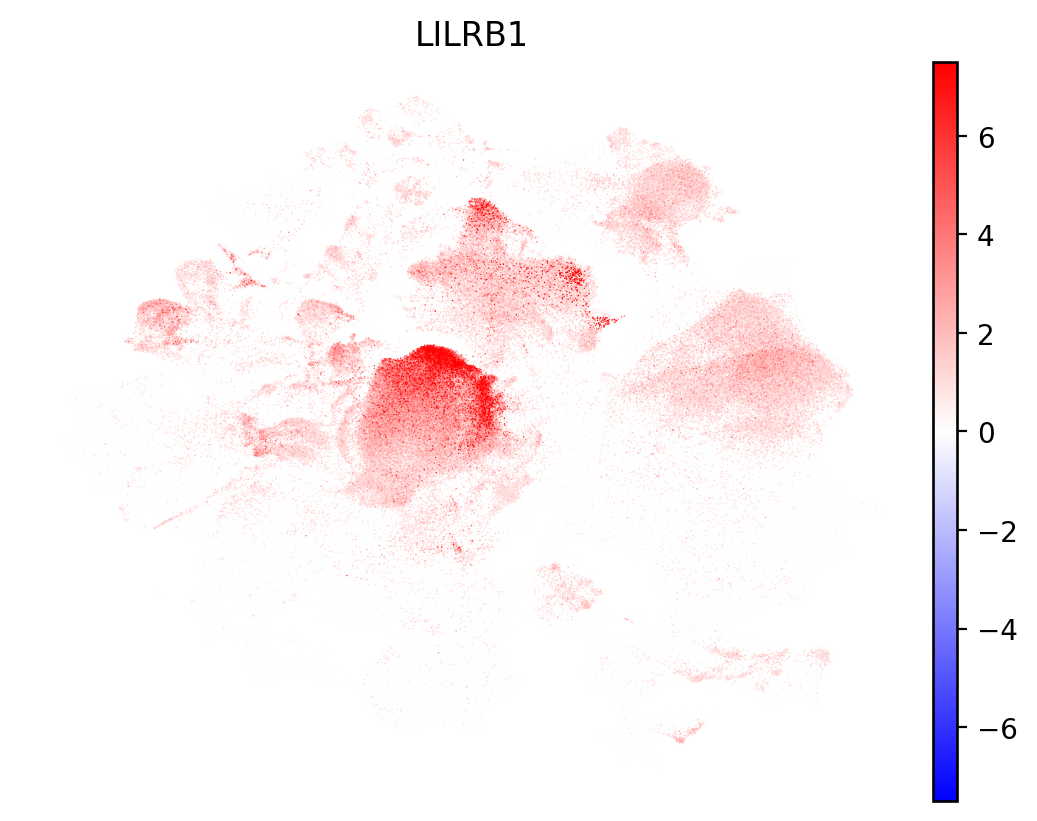

In [43]:
fig = sc.pl.umap(
    adata,
    color="LILRB1",
    vmax=7.5,
    vmin=-7.5,
    cmap="bwr",
    size=1,
    frameon=False,
    return_fig=True,
)
fig.savefig(plot_dir / "adata_all_umap_LILRB1.png", dpi=300, bbox_inches="tight")
print(f"Saved: {plot_dir / 'adata_all_umap_LILRB1.png'}")
plt.show()


In [20]:
from matplotlib.colors import Normalize

# =========================================================
# COLOR BY % LILRB1+ CELLS
# =========================================================
norm = Normalize(vmin=0, vmax=75)

scat = ax.scatter(
    dot_df["x"],
    dot_df["y"],
    s=dot_df["dot_size"],
    c=dot_df["pct_positive"],
    cmap="RdBu_r",
    norm=norm,
    edgecolors="0.30",
    linewidths=0.25,
    alpha=0.95
)

cax = fig.add_axes([0.76, 0.25, 0.025, 0.48])
cbar = fig.colorbar(scat, cax=cax)
cbar.set_label("% cells LILRB1+", fontsize=11)
cbar.ax.tick_params(labelsize=9)

Saved: /samurlab1/Joshua/ipynb_store/LILRB1/plots/LILRB1_full_preserved_stage_model_dotplot.png


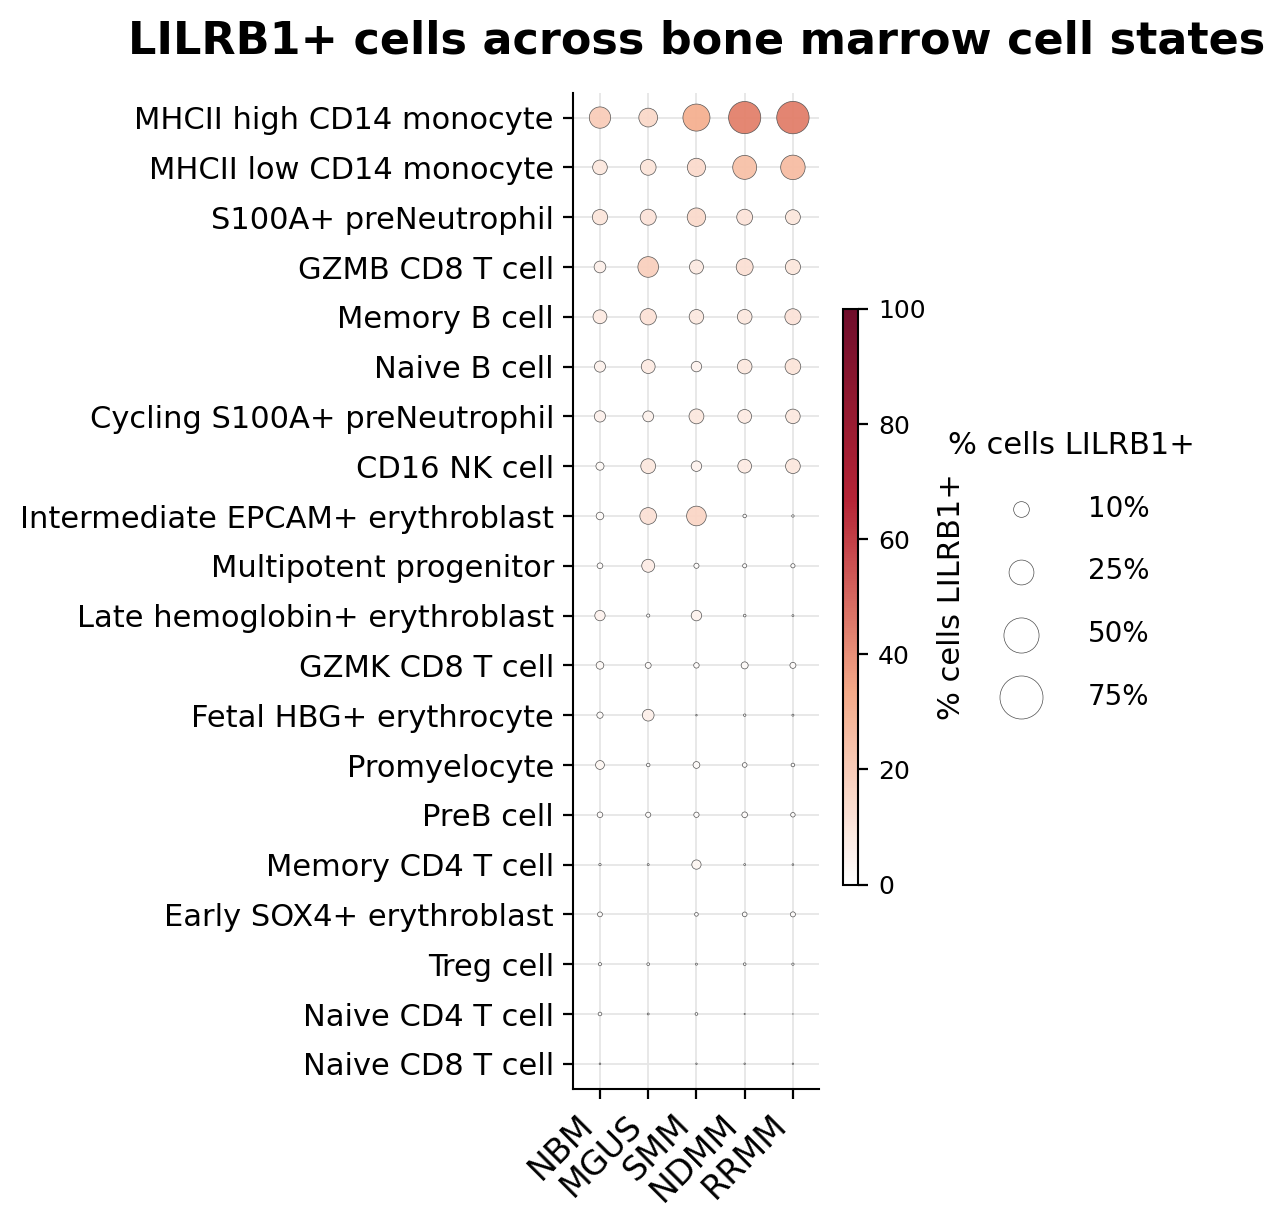

In [44]:
# =========================================================
# LILRB1 DOTPLOT - full adata, preserved x stage_model
# Dot size  = % cells expressing LILRB1
# Dot color = % cells expressing LILRB1
# =========================================================

gene = "LILRB1"
celltype_col = "preserved"
stage_col = "stage_model"

stage_order = ["NBM", "MGUS", "SMM", "NDMM", "RRMM"]
top_n = 20
size_scale = 3.2

if gene not in adata.var_names:
    raise ValueError(f"{gene} not found in adata.var_names")
if celltype_col not in adata.obs.columns:
    raise ValueError(f"{celltype_col} not found in adata.obs")
if stage_col not in adata.obs.columns:
    raise ValueError(f"{stage_col} not found in adata.obs")

adata_plot = adata.copy()

X = adata_plot.layers["counts"] if "counts" in adata_plot.layers else adata_plot.X
gidx = adata_plot.var_names.get_loc(gene)
expr = X[:, gidx]
expr = expr.toarray().ravel() if hasattr(expr, "toarray") else np.asarray(expr).ravel()

adata_plot.obs[f"{gene}_counts"] = expr
adata_plot.obs[f"{gene}_positive"] = expr > 0

df = pd.DataFrame({
    "celltype": adata_plot.obs[celltype_col].astype(str).values,
    "stage": adata_plot.obs[stage_col].astype(str).values,
    "counts": adata_plot.obs[f"{gene}_counts"].values,
    "positive": adata_plot.obs[f"{gene}_positive"].values,
}, index=adata_plot.obs_names)

df = df.dropna(subset=["celltype", "stage", "counts", "positive"])
df = df[df["stage"].isin(stage_order)]
df = df[~df["celltype"].isin(["NA", "nan", "None", "<NA>"])]

celltype_order = df["celltype"].value_counts().head(top_n).index.tolist()
df = df[df["celltype"].isin(celltype_order)]

dot_df = (
    df.groupby(["celltype", "stage"], observed=True)
      .agg(
          pct_positive=("positive", lambda x: x.mean() * 100),
          mean_counts=("counts", "mean"),
          median_counts=("counts", "median"),
          n_cells=("counts", "size")
      )
      .reset_index()
)

grid = pd.MultiIndex.from_product(
    [celltype_order, stage_order],
    names=["celltype", "stage"]
).to_frame(index=False)

dot_df = grid.merge(dot_df, on=["celltype", "stage"], how="left")

dot_df["pct_positive"] = dot_df["pct_positive"].fillna(0)
dot_df["mean_counts"] = dot_df["mean_counts"].fillna(0)
dot_df["median_counts"] = dot_df["median_counts"].fillna(0)
dot_df["n_cells"] = dot_df["n_cells"].fillna(0).astype(int)

order_df = (
    dot_df.groupby("celltype", observed=True)["pct_positive"]
    .mean()
    .sort_values(ascending=False)
)
celltype_order = order_df.index.tolist()

dot_df["celltype"] = pd.Categorical(dot_df["celltype"], categories=celltype_order, ordered=True)
dot_df["stage"] = pd.Categorical(dot_df["stage"], categories=stage_order, ordered=True)
dot_df["x"] = dot_df["stage"].cat.codes
dot_df["y"] = dot_df["celltype"].cat.codes
dot_df["dot_size"] = dot_df["pct_positive"] * size_scale

mpl.rcParams.update({
    "font.family": "DejaVu Sans",
    "axes.linewidth": 0.75,
    "figure.dpi": 200,
})

fig, ax = plt.subplots(figsize=(3, 6))
white_red = LinearSegmentedColormap.from_list(
    "white_to_red",
    ["white", "#f4a582", "#b2182b", "#67001f"]
)
norm = Normalize(vmin=0, vmax=100)

scat = ax.scatter(
    dot_df["x"],
    dot_df["y"],
    s=dot_df["dot_size"],
    c=dot_df["pct_positive"],
    cmap=white_red,
    norm=norm,
    edgecolors="0.30",
    linewidths=0.25,
    alpha=0.95
)

ax.set_xticks(range(len(stage_order)))
ax.set_xticklabels(stage_order, fontsize=12, rotation=45, ha="right")
ax.set_yticks(range(len(celltype_order)))
ax.set_yticklabels(celltype_order, fontsize=11)
ax.invert_yaxis()
ax.set_xlabel("")
ax.set_ylabel("")
ax.set_title(f"{gene}+ cells across bone marrow cell states", fontsize=16, weight="bold", pad=14)
ax.grid(axis="both", color="0.90", linewidth=0.65)
ax.set_axisbelow(True)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_xlim(-0.55, len(stage_order) - 0.45)
ax.set_ylim(len(celltype_order) - 0.5, -0.5)
fig.subplots_adjust(left=0.31, right=0.72, top=0.91, bottom=0.08)

cax = fig.add_axes([0.76, 0.25, 0.025, 0.48])
cbar = fig.colorbar(scat, cax=cax)
cbar.set_label(f"% cells {gene}+", fontsize=11)
cbar.ax.tick_params(labelsize=9)

legend_sizes = [10, 25, 50, 75]
handles = [
    ax.scatter([], [], s=p * size_scale, c="white", edgecolors="0.30", linewidths=0.25)
    for p in legend_sizes
]
ax.legend(
    handles,
    [f"{p}%" for p in legend_sizes],
    title=f"% cells {gene}+",
    frameon=False,
    bbox_to_anchor=(1.42, 0.52),
    loc="center left",
    fontsize=10,
    title_fontsize=11,
    labelspacing=1.25,
    handletextpad=1.4
)

out_png = plot_dir / "LILRB1_full_preserved_stage_model_dotplot.png"
fig.savefig(out_png, dpi=300, bbox_inches="tight")
print(f"Saved: {out_png}")
plt.show()

In [45]:
# =========================================================
# Subset red-highlighted / selected datasets
# =========================================================
keep_datasets = [
    "DISCO_ref",
    "GSE124310_MM_immune_RAW",
    "GSE271107_MM_precursors",
    "GSE169396_femoral_27k",
    "GSE194122_BMMC",
    "GSE253355_noanno",
]

adata_sub = adata[adata.obs["dataset"].isin(keep_datasets)].copy()

print(adata_sub)
print(pd.crosstab(adata_sub.obs["dataset"], adata_sub.obs["stage_model"]))

if "counts" in adata.layers:
    adata_sub.layers["counts"] = adata_sub.layers["counts"].copy()

# =========================================================
# Reclustering workflow
# =========================================================
sc.pp.normalize_total(adata_sub, target_sum=1e4)
sc.pp.log1p(adata_sub)

sc.pp.highly_variable_genes(
    adata_sub,
    n_top_genes=3000,
    flavor="seurat_v3",
    layer="counts" if "counts" in adata_sub.layers else None,
    subset=False,
)

sc.pp.pca(
    adata_sub,
    n_comps=50,
    use_highly_variable=True,
)

sc.pp.neighbors(
    adata_sub,
    n_neighbors=15,
    n_pcs=40,
)

sc.tl.umap(adata_sub)

sc.tl.leiden(
    adata_sub,
    resolution=0.5,
    key_added="leiden_red_subset",
)

AnnData object with n_obs × n_vars = 681607 × 15412
    obs: 'sample', 'biological_sample_id', 'dataset', 'stage_raw', 'collection_event_raw', 'stage_model', 'event_model', 'age_years', 'sex', 'preserved', 'macro_cell_type', 'macro_cell_type_v2', 'macro_cell_type_old', 'sample_clean', 'feature_module_score', 'feature_module_score_z', 'stage_model_v2'
    uns: 'dataset_colors', 'integration_origin_colors', 'macro_cell_type_colors', 'macro_cell_type_v2_colors', 'neighbors', 'preserved_colors', 'stage_colors', 'stage_model_colors', 'stage_model_repaired_colors', 'stage_model_v2_colors', 'umap'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_harmony', 'X_integrated', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap', 'X_umap.sub', 'X_umap_dim30'
    layers: 'counts'
    obsp: 'connectivities', 'distances'
stage_model               MGUS     MM     NBM    SMM
dataset                                             
DISCO_ref                    0 

Saved: /samurlab1/Joshua/ipynb_store/LILRB1/plots/adata_sub_umap_dataset_stage_model_leiden.png


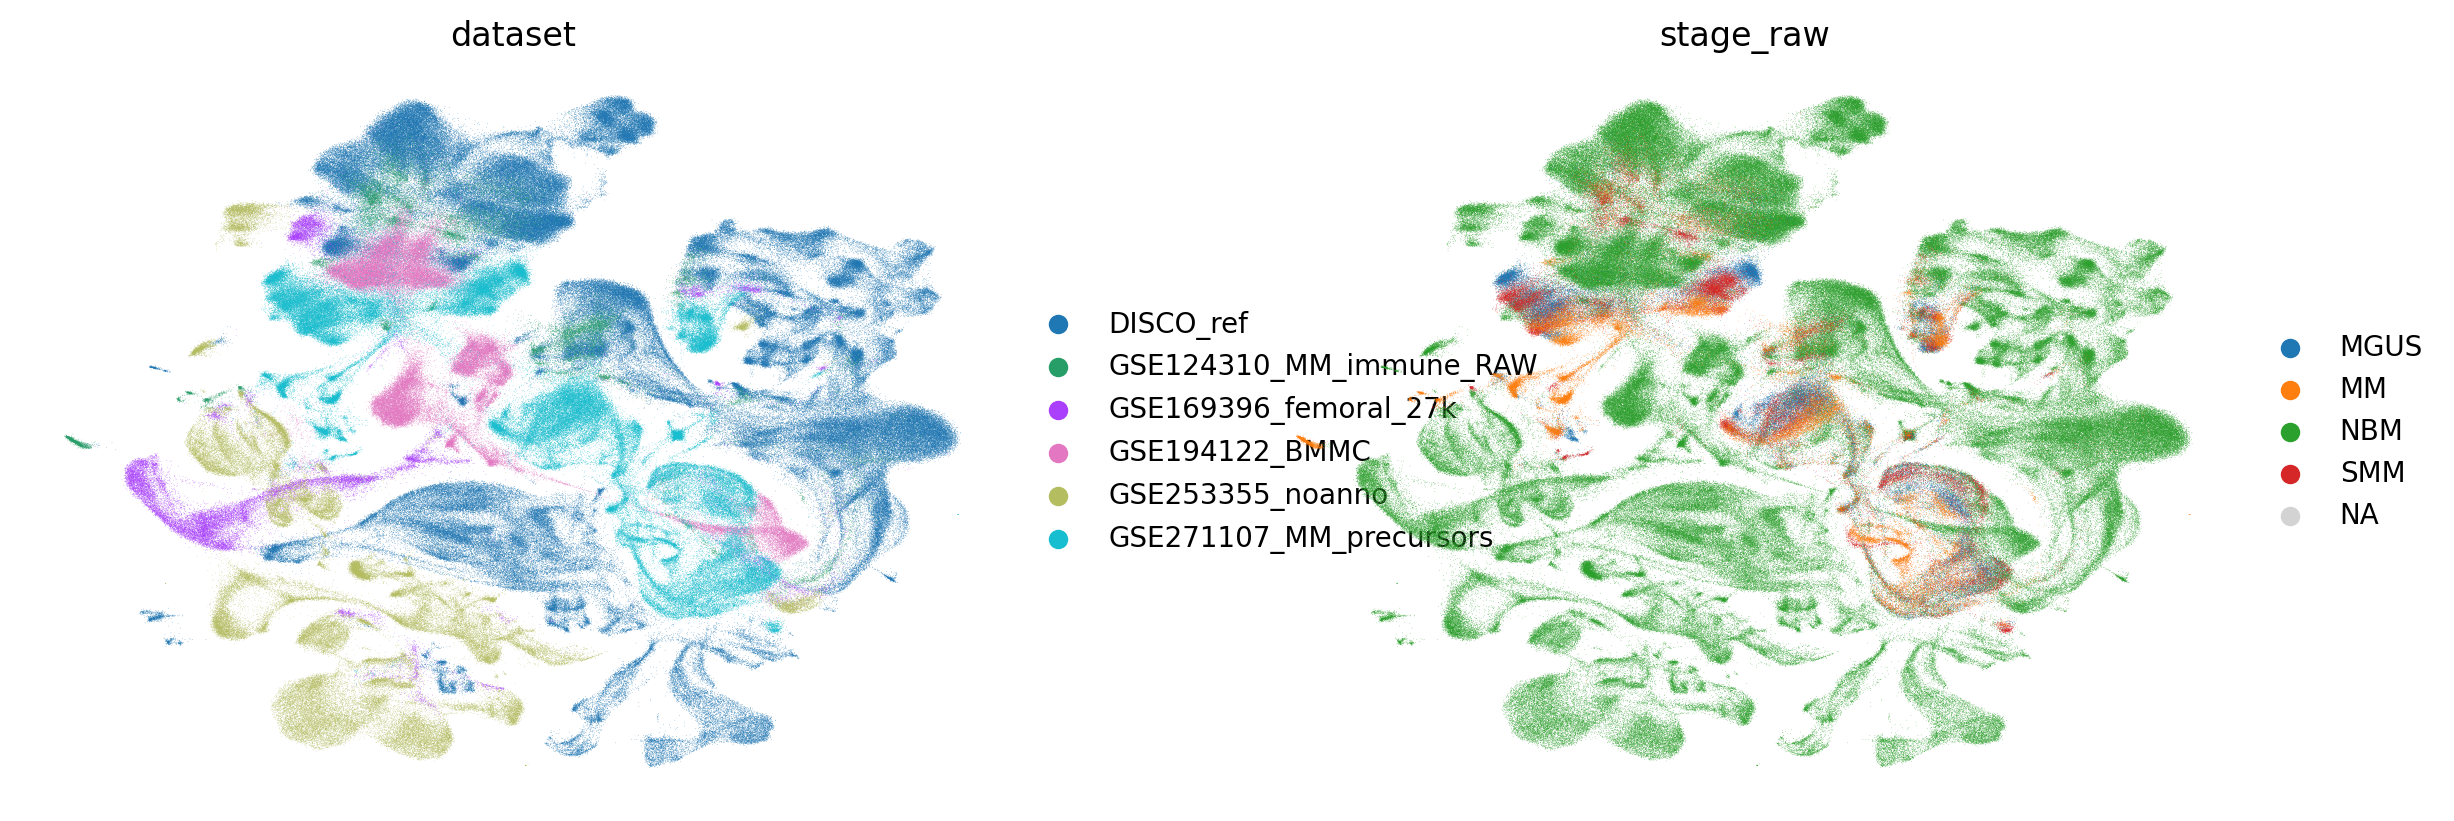

In [46]:
fig = sc.pl.umap(
    adata_sub,
    color=["dataset", "stage_raw"],
    frameon=False,
    return_fig=True,
)
fig.savefig(plot_dir / "adata_sub_umap_dataset_stage_model_leiden.png", dpi=300, bbox_inches="tight")
print(f"Saved: {plot_dir / 'adata_sub_umap_dataset_stage_model_leiden.png'}")
plt.show()


Saved: /samurlab1/Joshua/ipynb_store/LILRB1/plots/adata_sub_umap_preserved.png


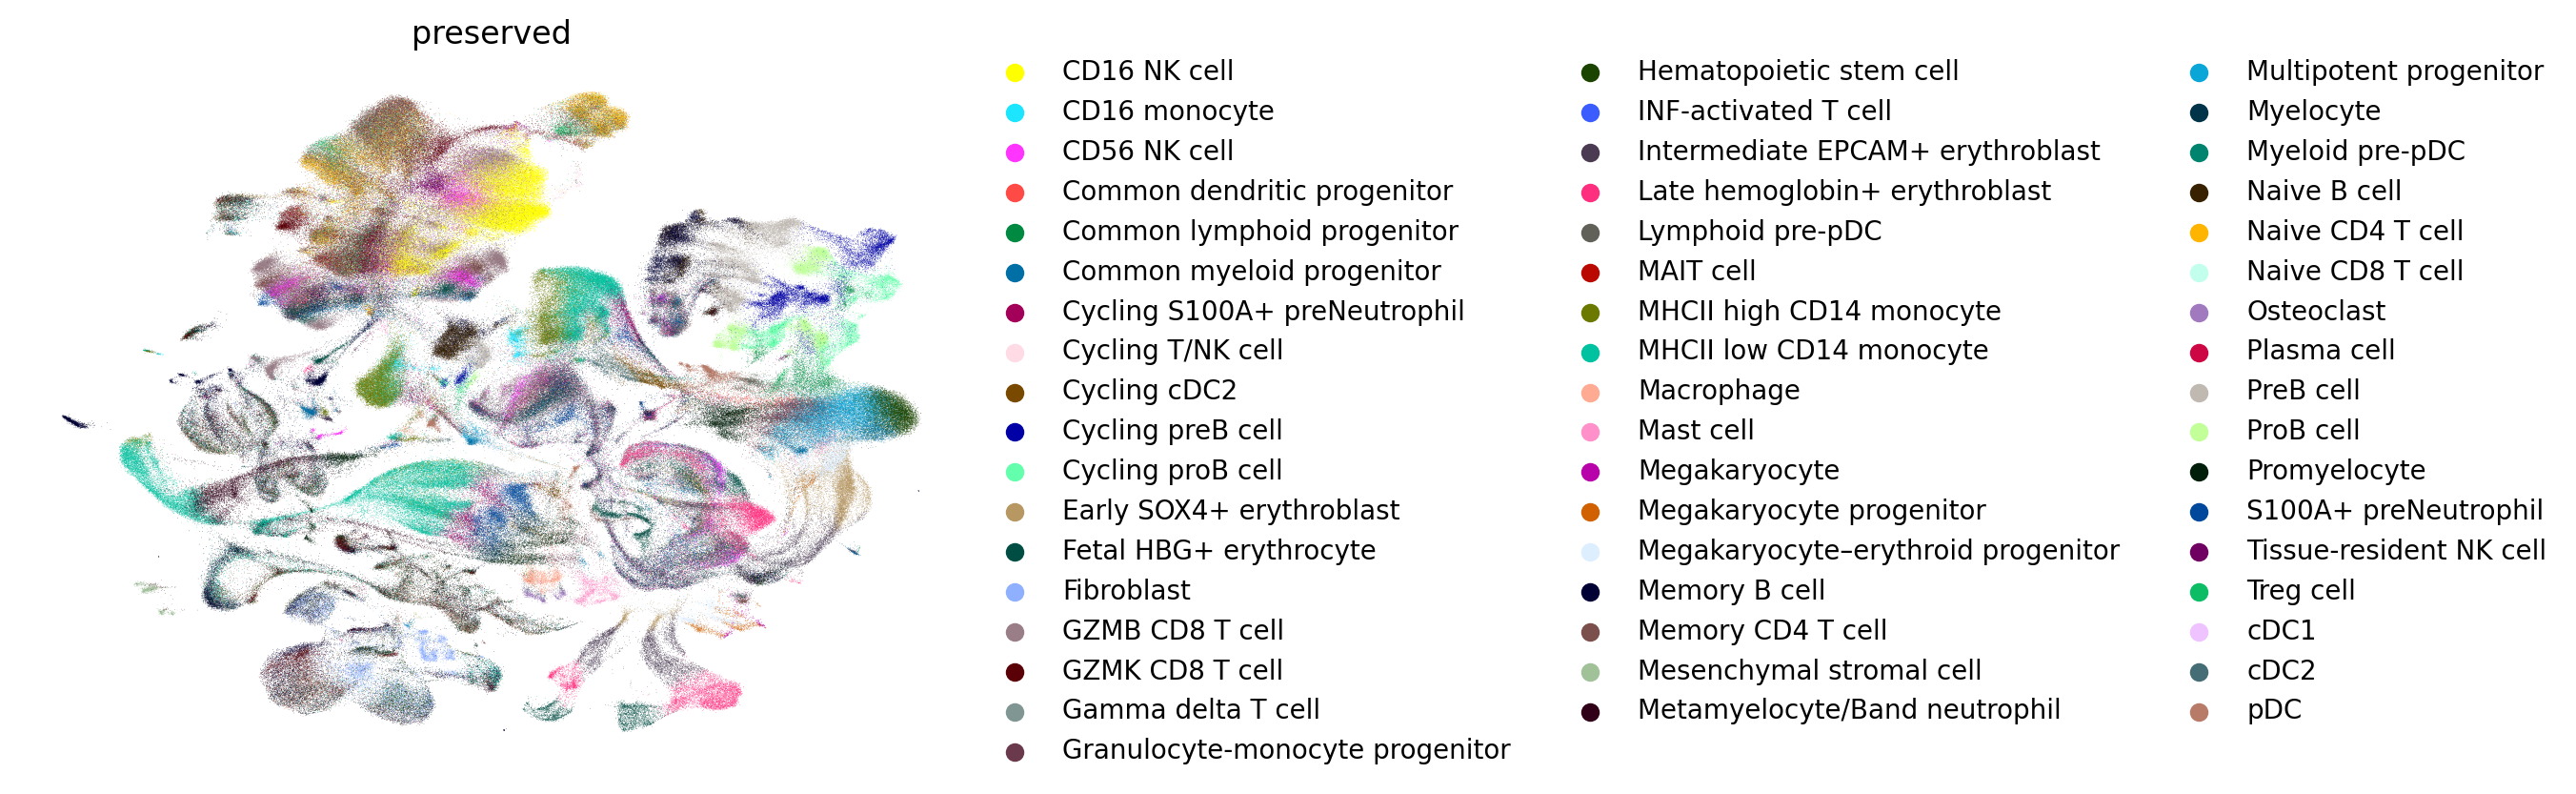

In [47]:
fig = sc.pl.umap(
    adata_sub,
    color=["preserved"],
    frameon=False,
    return_fig=True,
)
fig.savefig(plot_dir / "adata_sub_umap_preserved.png", dpi=300, bbox_inches="tight")
print(f"Saved: {plot_dir / 'adata_sub_umap_preserved.png'}")
plt.show()

Saved: /samurlab1/Joshua/ipynb_store/LILRB1/plots/adata_sub_umap_macro_cell_type_v2.png


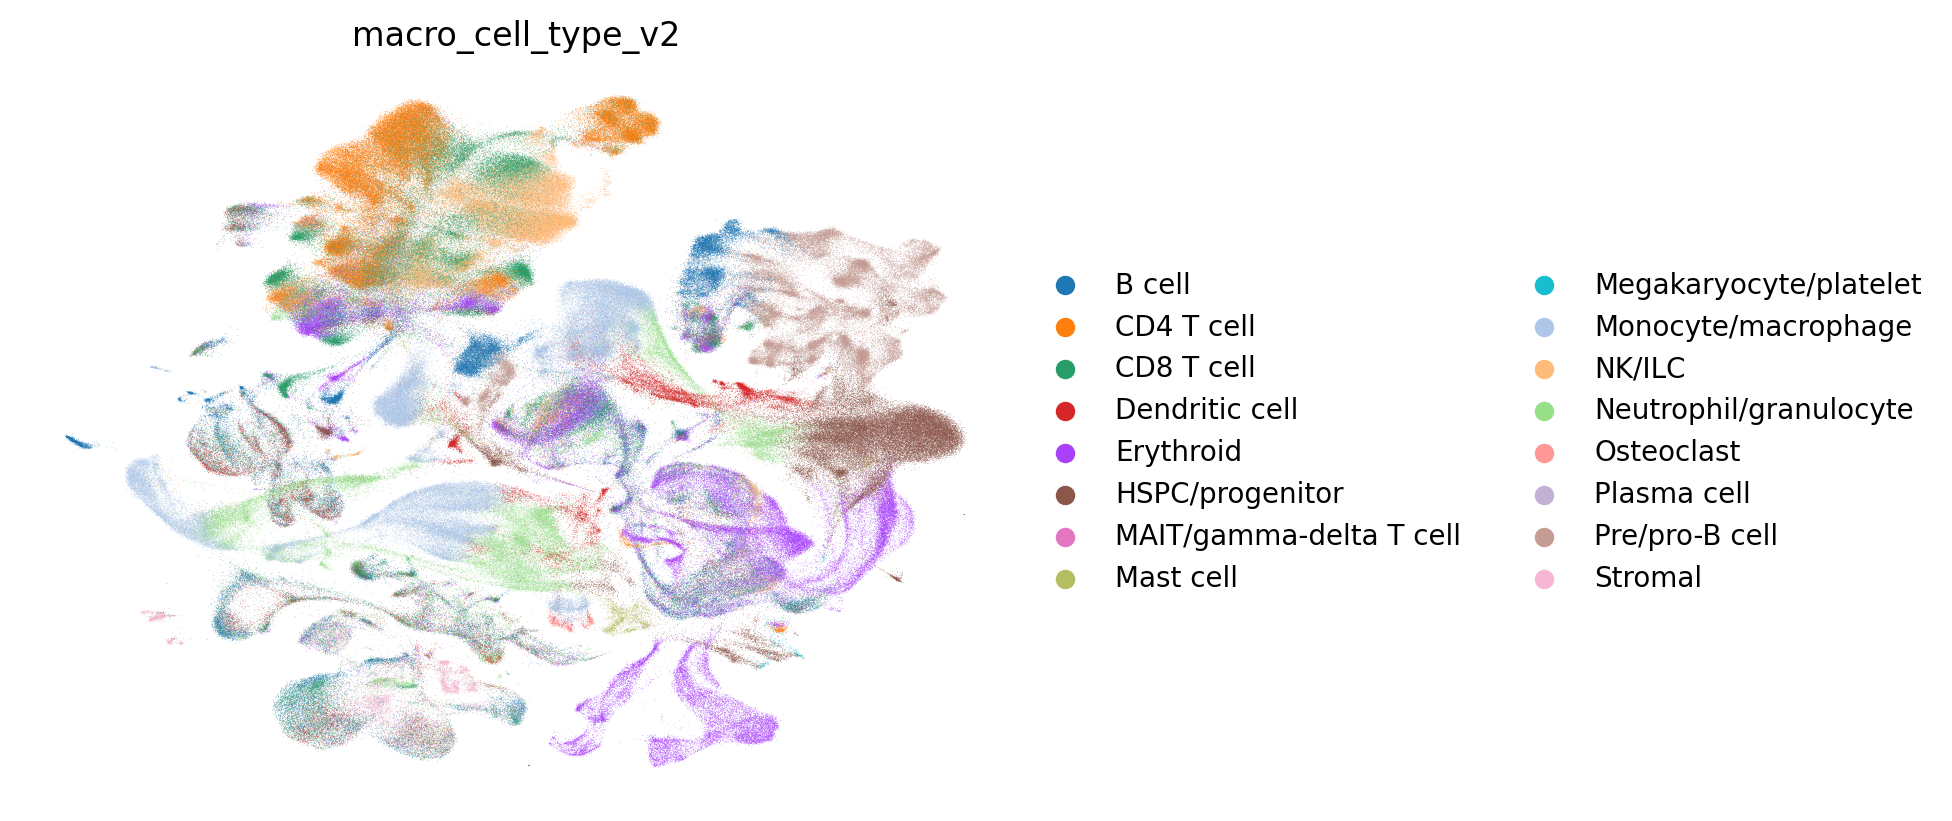

In [48]:
fig = sc.pl.umap(
    adata_sub,
    color=["macro_cell_type_v2"],
    frameon=False,
    return_fig=True,
)
fig.savefig(plot_dir / "adata_sub_umap_macro_cell_type_v2.png", dpi=300, bbox_inches="tight")
print(f"Saved: {plot_dir / 'adata_sub_umap_macro_cell_type_v2.png'}")
plt.show()


Saved: /samurlab1/Joshua/ipynb_store/LILRB1/plots/adata_sub_umap_stage_raw.png


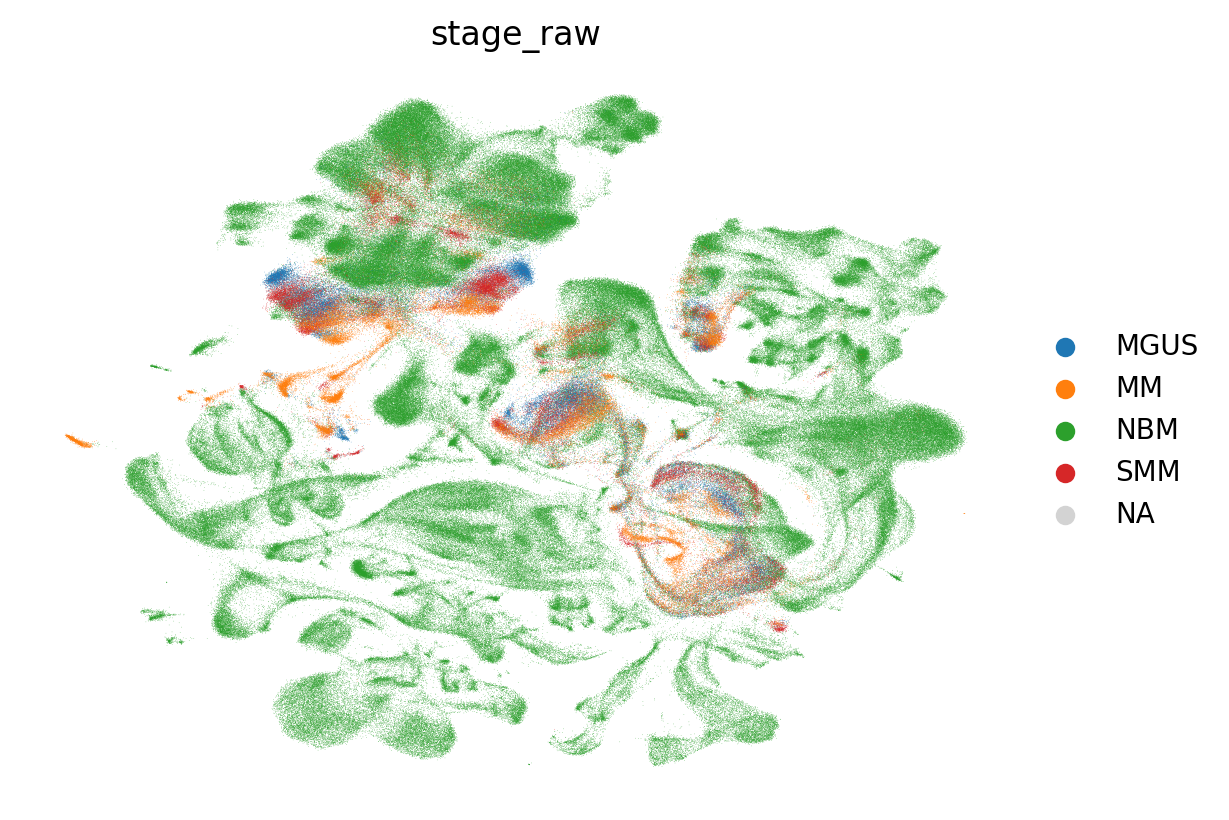

In [49]:
fig = sc.pl.umap(
    adata_sub,
    color=["stage_raw"],
    frameon=False,
    return_fig=True,
)
fig.savefig(plot_dir / "adata_sub_umap_stage_raw.png", dpi=300, bbox_inches="tight")
print(f"Saved: {plot_dir / 'adata_sub_umap_stage_raw.png'}")
plt.show()


Saved: /samurlab1/Joshua/ipynb_store/LILRB1/plots/adata_sub_umap_LILRB1.png


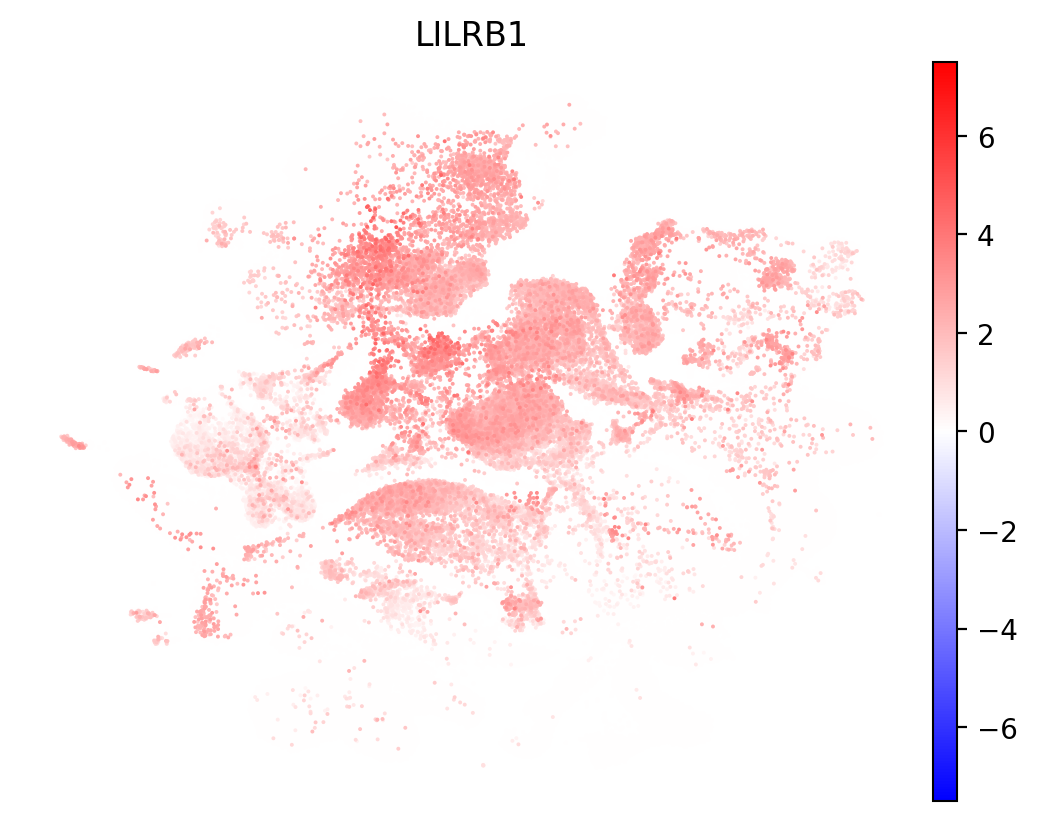

In [50]:
fig = sc.pl.umap(
    adata_sub,
    color="LILRB1",
    vmax=7.5,
    vmin=-7.5,
    cmap="bwr",
    size=8,
    frameon=False,
    return_fig=True,
)
fig.savefig(plot_dir / "adata_sub_umap_LILRB1.png", dpi=300, bbox_inches="tight")
print(f"Saved: {plot_dir / 'adata_sub_umap_LILRB1.png'}")
plt.show()

In [51]:
adata_sub.write_h5ad("/samurlab1/Joshua/ipynb_store/LILRB1/data/adata_subset.h5ad")

AnnData object with n_obs × n_vars = 681607 × 15412
    obs: 'sample', 'biological_sample_id', 'dataset', 'stage_raw', 'collection_event_raw', 'stage_model', 'event_model', 'age_years', 'sex', 'preserved', 'macro_cell_type', 'macro_cell_type_v2', 'macro_cell_type_old', 'sample_clean', 'feature_module_score', 'feature_module_score_z', 'stage_model_v2', 'leiden_red_subset'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_colors', 'integration_origin_colors', 'macro_cell_type_colors', 'macro_cell_type_v2_colors', 'neighbors', 'preserved_colors', 'stage_colors', 'stage_model_colors', 'stage_model_repaired_colors', 'stage_model_v2_colors', 'umap', 'log1p', 'hvg', 'pca', 'leiden_red_subset', 'stage_raw_colors'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_harmony', 'X_integrated', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap', 'X_umap.sub', 'X_umap_dim30'
    varm: 'PCs'
    la

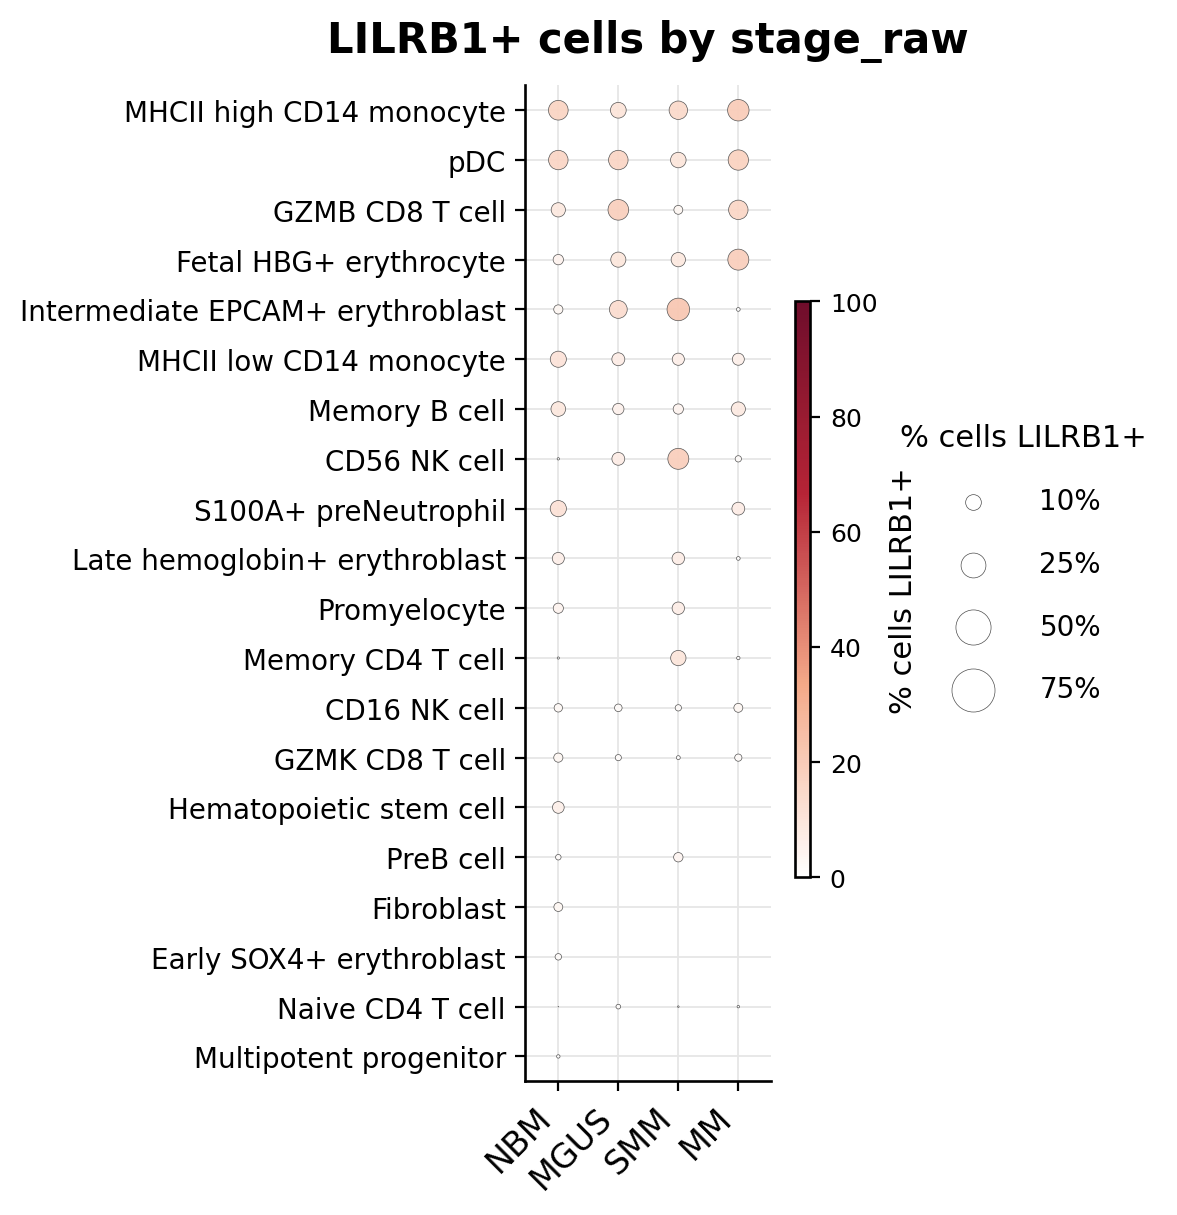

AnnData object with n_obs × n_vars = 681607 × 15412
    obs: 'sample', 'biological_sample_id', 'dataset', 'stage_raw', 'collection_event_raw', 'stage_model', 'event_model', 'age_years', 'sex', 'preserved', 'macro_cell_type', 'macro_cell_type_v2', 'macro_cell_type_old', 'sample_clean', 'feature_module_score', 'feature_module_score_z', 'stage_model_v2', 'leiden_red_subset'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_colors', 'integration_origin_colors', 'macro_cell_type_colors', 'macro_cell_type_v2_colors', 'neighbors', 'preserved_colors', 'stage_colors', 'stage_model_colors', 'stage_model_repaired_colors', 'stage_model_v2_colors', 'umap', 'log1p', 'hvg', 'pca', 'leiden_red_subset', 'stage_raw_colors'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_harmony', 'X_integrated', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap', 'X_umap.sub', 'X_umap_dim30'
    varm: 'PCs'
    la

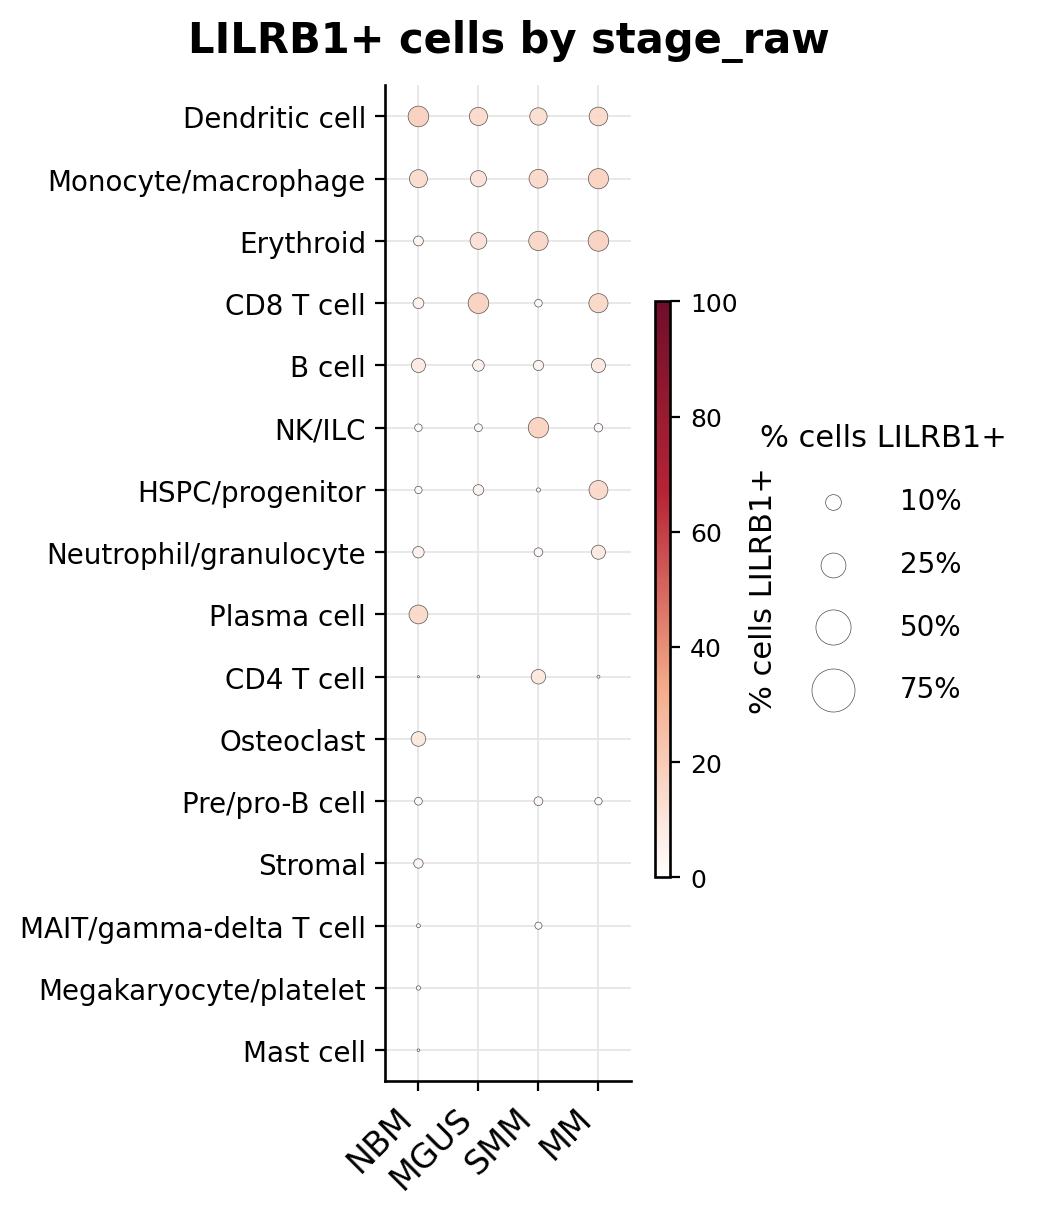

AnnData object with n_obs × n_vars = 681607 × 15412
    obs: 'sample', 'biological_sample_id', 'dataset', 'stage_raw', 'collection_event_raw', 'stage_model', 'event_model', 'age_years', 'sex', 'preserved', 'macro_cell_type', 'macro_cell_type_v2', 'macro_cell_type_old', 'sample_clean', 'feature_module_score', 'feature_module_score_z', 'stage_model_v2', 'leiden_red_subset'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_colors', 'integration_origin_colors', 'macro_cell_type_colors', 'macro_cell_type_v2_colors', 'neighbors', 'preserved_colors', 'stage_colors', 'stage_model_colors', 'stage_model_repaired_colors', 'stage_model_v2_colors', 'umap', 'log1p', 'hvg', 'pca', 'leiden_red_subset', 'stage_raw_colors'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_harmony', 'X_integrated', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap', 'X_umap.sub', 'X_umap_dim30'
    varm: 'PCs'
    la

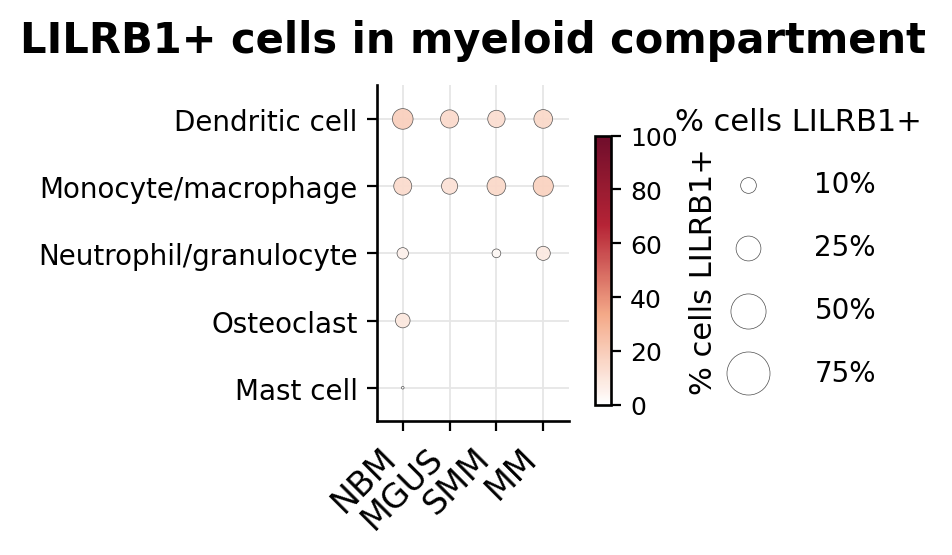

AnnData object with n_obs × n_vars = 681607 × 15412
    obs: 'sample', 'biological_sample_id', 'dataset', 'stage_raw', 'collection_event_raw', 'stage_model', 'event_model', 'age_years', 'sex', 'preserved', 'macro_cell_type', 'macro_cell_type_v2', 'macro_cell_type_old', 'sample_clean', 'feature_module_score', 'feature_module_score_z', 'stage_model_v2', 'leiden_red_subset'
    var: 'highly_variable', 'highly_variable_rank', 'means', 'variances', 'variances_norm'
    uns: 'dataset_colors', 'integration_origin_colors', 'macro_cell_type_colors', 'macro_cell_type_v2_colors', 'neighbors', 'preserved_colors', 'stage_colors', 'stage_model_colors', 'stage_model_repaired_colors', 'stage_model_v2_colors', 'umap', 'log1p', 'hvg', 'pca', 'leiden_red_subset', 'stage_raw_colors'
    obsm: 'ATAC_gene_activity', 'ATAC_lsi_full', 'ATAC_lsi_red', 'ATAC_umap', 'GEX_X_pca', 'GEX_X_umap', 'X_harmony', 'X_integrated', 'X_pca', 'X_scANVI', 'X_scVI', 'X_umap', 'X_umap.sub', 'X_umap_dim30'
    varm: 'PCs'
    la

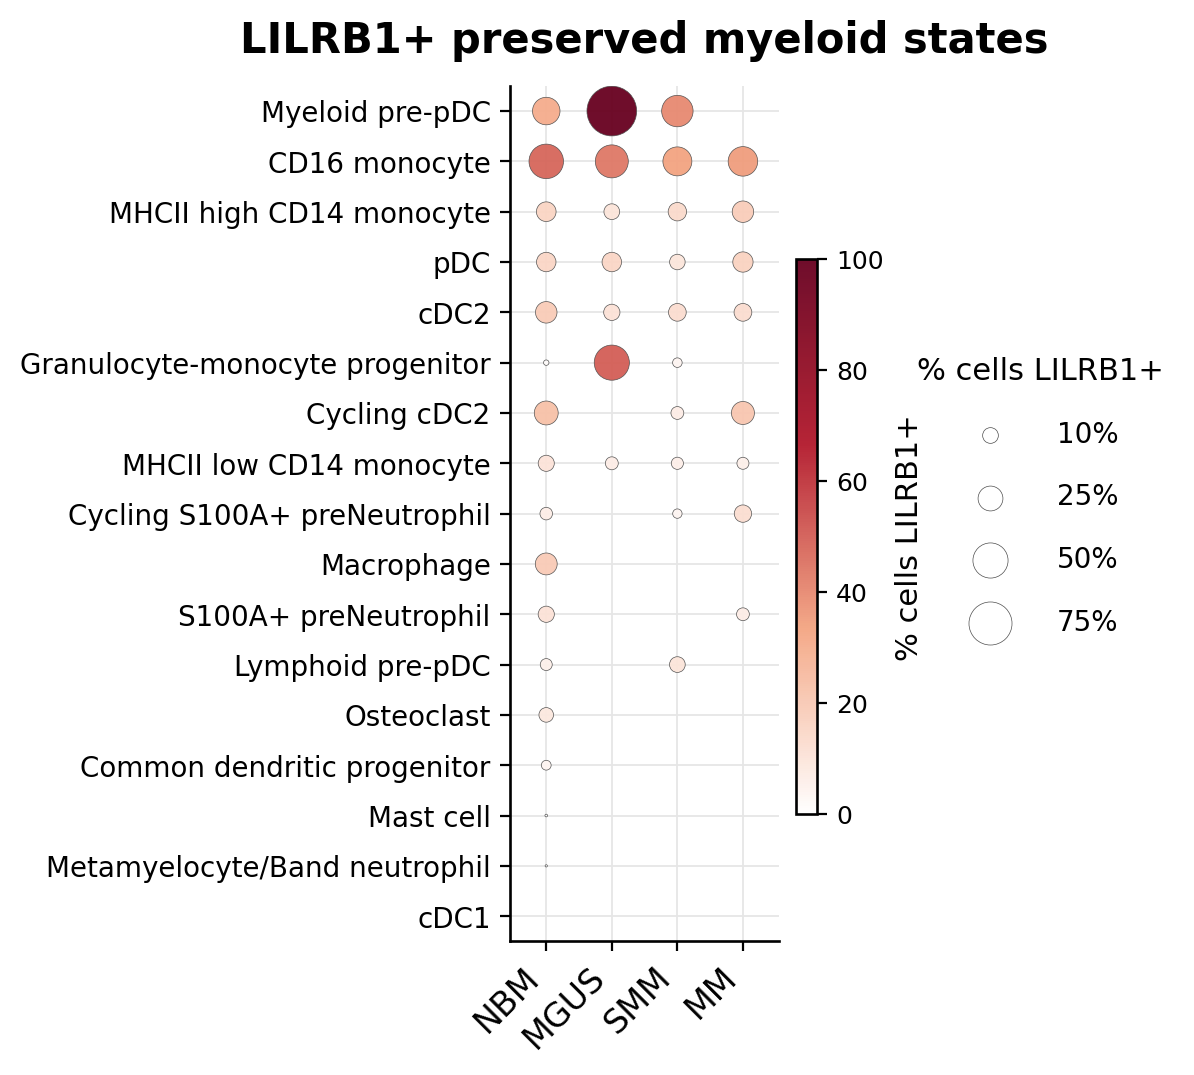

In [52]:
# =========================================================
# Helper function for repeated dotplot logic
# =========================================================
def lilrb1_dotplot(
    adata_in,
    gene="LILRB1",
    celltype_col="preserved",
    stage_col="stage_raw",
    stage_order=None,
    top_n=20,
    size_scale=3.2,
    title=None,
    output_name="LILRB1_dotplot.png",
    myeloid_celltypes=None,
    myeloid_patterns=None,
    figsize=(3, 6),
    subplots_adjust=None,
):
    if stage_order is None:
        stage_order = ["NBM", "MGUS", "SMM", "MM"]

    adata_plot = adata_in.copy()

    if gene not in adata_plot.var_names:
        raise ValueError(f"{gene} not found in adata_in.var_names")
    if celltype_col not in adata_plot.obs.columns:
        raise ValueError(f"{celltype_col} not found in adata_in.obs")
    if stage_col not in adata_plot.obs.columns:
        raise ValueError(f"{stage_col} not found in adata_in.obs")

    print(adata_plot)
    print(pd.crosstab(adata_plot.obs["dataset"], adata_plot.obs[stage_col]))

    X = adata_plot.layers["counts"] if "counts" in adata_plot.layers else adata_plot.X
    gidx = adata_plot.var_names.get_loc(gene)
    expr = X[:, gidx]
    expr = expr.toarray().ravel() if hasattr(expr, "toarray") else np.asarray(expr).ravel()

    adata_plot.obs[f"{gene}_counts"] = expr
    adata_plot.obs[f"{gene}_positive"] = expr > 0

    df = pd.DataFrame({
        "celltype": adata_plot.obs[celltype_col].astype(str).values,
        "stage": adata_plot.obs[stage_col].astype(str).values,
        "counts": adata_plot.obs[f"{gene}_counts"].values,
        "positive": adata_plot.obs[f"{gene}_positive"].values,
    }, index=adata_plot.obs_names)

    df = df.dropna(subset=["celltype", "stage", "counts", "positive"])
    df = df[df["stage"].isin(stage_order)]
    df = df[~df["celltype"].isin(["NA", "nan", "None", "<NA>"])]

    if myeloid_celltypes is not None:
        df = df[df["celltype"].isin(myeloid_celltypes)].copy()
        celltype_order = [ct for ct in myeloid_celltypes if ct in df["celltype"].unique()]
        print("Cells after stage_raw + myeloid filtering:")
        print(pd.crosstab(df["celltype"], df["stage"]).reindex(index=myeloid_celltypes, columns=stage_order).fillna(0).astype(int))
    elif myeloid_patterns is not None:
        pattern_regex = "|".join(myeloid_patterns)
        df = df[
            df["celltype"]
            .str.lower()
            .str.contains(pattern_regex, regex=True, na=False)
        ].copy()
        print("Myeloid-like preserved labels retained:")
        print(sorted(df["celltype"].unique()))
        print("\nCells after stage_raw + preserved-myeloid filtering:")
        print(pd.crosstab(df["celltype"], df["stage"]).reindex(columns=stage_order).fillna(0).astype(int))
        celltype_order = (
            df.groupby("celltype")["positive"]
              .mean()
              .sort_values(ascending=False)
              .index
              .tolist()
        )
    else:
        print("Cells after stage_raw filtering:")
        print(df["stage"].value_counts().reindex(stage_order).fillna(0).astype(int))
        celltype_order = df["celltype"].value_counts().head(top_n).index.tolist()
        df = df[df["celltype"].isin(celltype_order)]

    dot_df = (
        df.groupby(["celltype", "stage"], observed=True)
          .agg(
              pct_positive=("positive", lambda x: x.mean() * 100),
              mean_counts=("counts", "mean"),
              median_counts=("counts", "median"),
              n_cells=("counts", "size")
          )
          .reset_index()
    )

    grid = pd.MultiIndex.from_product(
        [celltype_order, stage_order],
        names=["celltype", "stage"]
    ).to_frame(index=False)

    dot_df = grid.merge(dot_df, on=["celltype", "stage"], how="left")
    dot_df["pct_positive"] = dot_df["pct_positive"].fillna(0)
    dot_df["mean_counts"] = dot_df["mean_counts"].fillna(0)
    dot_df["median_counts"] = dot_df["median_counts"].fillna(0)
    dot_df["n_cells"] = dot_df["n_cells"].fillna(0).astype(int)

    order_df = (
        dot_df.groupby("celltype", observed=True)["pct_positive"]
        .mean()
        .sort_values(ascending=False)
    )
    celltype_order = order_df.index.tolist()

    dot_df["celltype"] = pd.Categorical(dot_df["celltype"], categories=celltype_order, ordered=True)
    dot_df["stage"] = pd.Categorical(dot_df["stage"], categories=stage_order, ordered=True)
    dot_df["x"] = dot_df["stage"].cat.codes
    dot_df["y"] = dot_df["celltype"].cat.codes
    dot_df["dot_size"] = dot_df["pct_positive"] * size_scale

    mpl.rcParams.update({
        "font.family": "DejaVu Sans",
        "axes.linewidth": 0.95,
        "figure.dpi": 200,
    })

    fig, ax = plt.subplots(figsize=figsize)

    white_red = LinearSegmentedColormap.from_list(
        "white_to_red",
        ["white", "#f4a582", "#b2182b", "#67001f"]
    )
    norm = Normalize(vmin=0, vmax=100)

    scat = ax.scatter(
        dot_df["x"],
        dot_df["y"],
        s=dot_df["dot_size"],
        c=dot_df["pct_positive"],
        cmap=white_red,
        norm=norm,
        edgecolors="0.30",
        linewidths=0.25,
        alpha=0.95
    )

    ax.set_xticks(range(len(stage_order)))
    ax.set_xticklabels(stage_order, fontsize=12, rotation=45, ha="right")
    ax.set_yticks(range(len(celltype_order)))
    ax.set_yticklabels(celltype_order, fontsize=10)
    ax.invert_yaxis()
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title(title if title is not None else f"{gene}+ cells by {stage_col}", fontsize=15, weight="bold", pad=12)
    ax.grid(axis="both", color="0.90", linewidth=0.65)
    ax.set_axisbelow(True)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlim(-0.55, len(stage_order) - 0.45)
    ax.set_ylim(len(celltype_order) - 0.5, -0.5)

    if subplots_adjust is not None:
        fig.subplots_adjust(**subplots_adjust)
    else:
        fig.subplots_adjust(left=0.31, right=0.72, top=0.91, bottom=0.08)

    cax = fig.add_axes([0.76, 0.25, 0.025, 0.48])
    cbar = fig.colorbar(scat, cax=cax)
    cbar.set_label(f"% cells {gene}+", fontsize=11)
    cbar.ax.tick_params(labelsize=9)

    legend_sizes = [10, 25, 50, 75]
    handles = [
        ax.scatter([], [], s=p * size_scale, c="white", edgecolors="0.30", linewidths=0.25)
        for p in legend_sizes
    ]
    ax.legend(
        handles,
        [f"{p}%" for p in legend_sizes],
        title=f"% cells {gene}+",
        frameon=False,
        bbox_to_anchor=(1.42, 0.52),
        loc="center left",
        fontsize=10,
        title_fontsize=11,
        labelspacing=1.25,
        handletextpad=1.4
    )

    out_png = plot_dir / output_name
    fig.savefig(out_png, dpi=300, bbox_inches="tight")
    print(f"Saved: {out_png}")
    plt.show()

    return dot_df

# =========================================================
# adata_sub dotplots, saved as PNG
# =========================================================

stage_order_sub = ["NBM", "MGUS", "SMM", "MM"]

# Full preserved labels, stage_raw
dot_df_preserved_all = lilrb1_dotplot(
    adata_sub,
    gene="LILRB1",
    celltype_col="preserved",
    stage_col="stage_raw",
    stage_order=stage_order_sub,
    top_n=20,
    size_scale=3.2,
    title="LILRB1+ cells by stage_raw",
    output_name="LILRB1_all_preserved_stage_raw_dotplot.png",
    figsize=(3, 6),
    subplots_adjust={"left": 0.31, "right": 0.72, "top": 0.91, "bottom": 0.08},
)

# Full macro_cell_type_v2 labels, stage_raw
dot_df_macro_all = lilrb1_dotplot(
    adata_sub,
    gene="LILRB1",
    celltype_col="macro_cell_type_v2",
    stage_col="stage_raw",
    stage_order=stage_order_sub,
    top_n=20,
    size_scale=3.2,
    title="LILRB1+ cells by stage_raw",
    output_name="LILRB1_all_macro_stage_raw_dotplot.png",
    figsize=(3, 6),
    subplots_adjust={"left": 0.31, "right": 0.72, "top": 0.91, "bottom": 0.08},
)

# Macro myeloid-only
myeloid_celltypes = [
    "Monocyte/macrophage",
    "Dendritic cell",
    "Neutrophil/granulocyte",
    "Mast cell",
    "Osteoclast",
]

dot_df_macro_myeloid = lilrb1_dotplot(
    adata_sub,
    gene="LILRB1",
    celltype_col="macro_cell_type_v2",
    stage_col="stage_raw",
    stage_order=stage_order_sub,
    size_scale=3.2,
    title="LILRB1+ cells in myeloid compartment",
    output_name="LILRB1_macro_myeloid_stage_raw_dotplot.png",
    myeloid_celltypes=myeloid_celltypes,
    figsize=(3.2, 2.8),
    subplots_adjust={"left": 0.42, "right": 0.72, "top": 0.82, "bottom": 0.22},
)

# Preserved myeloid-only
myeloid_preserved_patterns = [
    "mono",
    "macrophage",
    "dendritic",
    "dc",
    "neutrophil",
    "granulocyte",
    "mast",
    "osteoclast",
]

# Height depends on retained labels, so do a quick estimate first for figsize
_preserved_vals = adata_sub.obs["preserved"].astype(str)
_myeloid_mask = _preserved_vals.str.lower().str.contains("|".join(myeloid_preserved_patterns), regex=True, na=False)
_n_myeloid_labels = _preserved_vals[_myeloid_mask].nunique()
fig_height = max(3, 0.34 * _n_myeloid_labels)

dot_df_preserved_myeloid = lilrb1_dotplot(
    adata_sub,
    gene="LILRB1",
    celltype_col="preserved",
    stage_col="stage_raw",
    stage_order=stage_order_sub,
    size_scale=3.2,
    title="LILRB1+ preserved myeloid states",
    output_name="LILRB1_preserved_myeloid_stage_raw_dotplot.png",
    myeloid_patterns=myeloid_preserved_patterns,
    figsize=(4.2, fig_height),
    subplots_adjust={"left": 0.42, "right": 0.74, "top": 0.88, "bottom": 0.14},
)
